In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xarray as xr
from scipy.signal import periodogram, find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose

# Annual components

In [67]:
def compute_periodogram(values):
    fs = 1.0  # Sampling frequency: 1 sample per hour
    freqs, power = periodogram(values, fs=fs)
    peaks, _ = find_peaks(power, height=100, distance=100) # peaks, properties
    peak_freqs = freqs[peaks]
    peak_periods = 1 / peak_freqs
    peak_periods = peak_periods[peak_periods < len(values)//2] # doesn't make sense to have a period longer than 1/2 * data
    peak_powers = power[peaks]
    peaks = [*zip(peak_periods, peak_powers)]
    return peaks

In [ ]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500 = z500.sel(time=slice('2000.1', '2017.12'))['z']

Latitude: 87.1875, Longitude: 28.125


In [ ]:
latitudes = np.arange(0, 32)
longitudes = np.arange(0, 64)
first_component = np.zeros((len(latitudes), len(longitudes)), dtype=float)
second_component = np.zeros((len(latitudes), len(longitudes)), dtype=float)

# Loop through each latitude and longitude and compute the periodogram for each - this takes a few minutes
for i, lat in enumerate(latitudes):
    for j, lon in enumerate(longitudes):
        loc = (slice(None),) + (lat, lon)
        time_series = z500[loc].values
        peaks = compute_periodogram(time_series)
        first_component[i, j] = peaks[0][0] if len(peaks) > 0 else np.nan
        second_component[i, j] = peaks[1][0] if len(peaks) > 1 else np.nan
    print('\r', f'{i+1}/{len(latitudes)}', end=' ')

Text(0.5, 1.1, 'Periods of the Fourier peaks for each grid point')

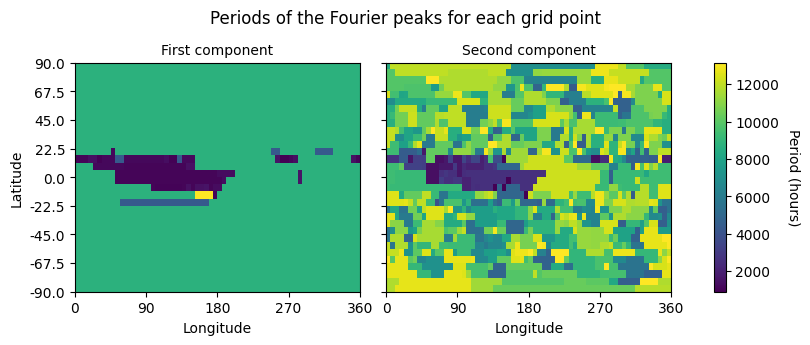

In [64]:
# Plot first and second Fourier peaks for each grid point
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True, layout='constrained')
ax1, ax2 = axs
cmap = ax1.imshow(first_component, cmap='viridis', aspect='auto', extent=(0, 64, 32, 0))
ax2.imshow(second_component, cmap='viridis', aspect='auto', extent=(0, 64, 32, 0))
cbar = fig.colorbar(cmap, ax=axs)
cbar.ax.get_yaxis().labelpad = 15
cbar.ax.set_ylabel('Period (hours)', rotation=270)
ax1.set_yticks(ticks=np.arange(0, 33, 4), labels=np.round(np.arange(0, -33, -4)*180/32 + 90, 1))
ax1.set_ylabel('Latitude')
for ax in axs:
    ax.set_xticks(ticks=np.arange(0, 65, 16), labels=np.round(np.arange(0, 65, 16)*360/64).astype(int))
    ax.set_xlabel('Longitude')
ax1.set_title('First component', fontsize=10)
ax2.set_title('Second component', fontsize=10)
fig.suptitle('Periods of the Fourier peaks for each grid point', y=1.1)

<Axes: >

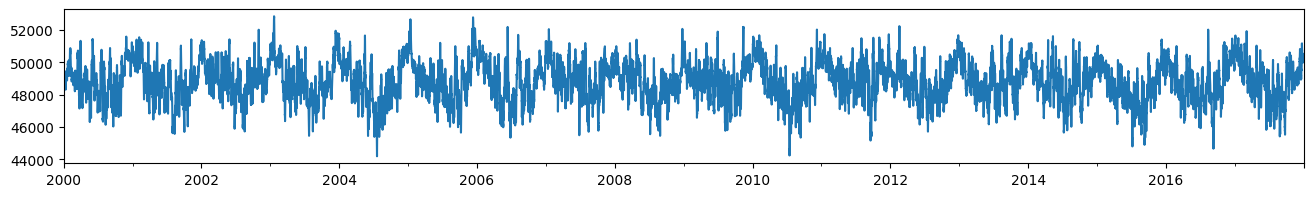

In [148]:
loc = (slice(None),) + (0, 48)
df = pd.Series(z500[loc].values, index=z500['time'].values)
df.plot(figsize=(16,2))
# plt.xlim(df.index[0], df.index[10000])

# Removing the highest annual component

Pick an arbitary point and remove the annual component using `seasonal_decompose`

In [ ]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500 = z500.sel(time=slice('2000.1', '2017.12'))['z']

loc = (slice(None),) + (31, 5)
df = pd.Series(z500[loc].values, index=z500['time'].values)
latitude = z500[loc].lat.values
longitude = z500[loc].lon.values
df.index.freq = 'h'
print(f'Latitude: {latitude}, Longitude: {longitude}')

Latitude: 87.1875, Longitude: 28.125


Text(0.5, 1.05, 'Seasonal decomposition of 500hPa geopotential at 87.2N, 28.1E')

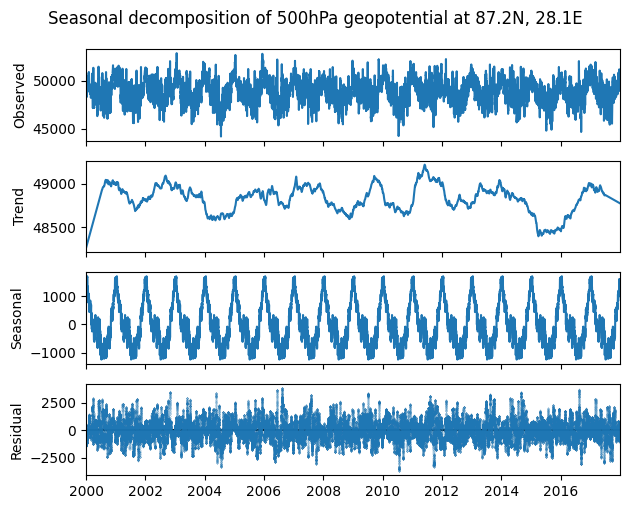

In [ ]:
# Plot the seasonal decomposition. The trend isn't useful because it isn't clear how it should be extrapolated
peaks = compute_periodogram(df.values)
results = seasonal_decompose(df, model='additive', extrapolate_trend=True, period=int(peaks[0][0]))
trend = results.trend
seasonal = results.seasonal

fig = results.plot()
fig.axes[0].set_ylabel('Observed')
fig.axes[-1].set_ylabel('Residual')
for line in fig.axes[-1].lines:
    line.set_markersize(.1)
fig.suptitle(f'Seasonal decomposition of 500hPa geopotential at {latitude:.1f}N, {longitude:.1f}E', y=1.05)
# fig.savefig('seasonal_decomposition.png', bbox_inches='tight')

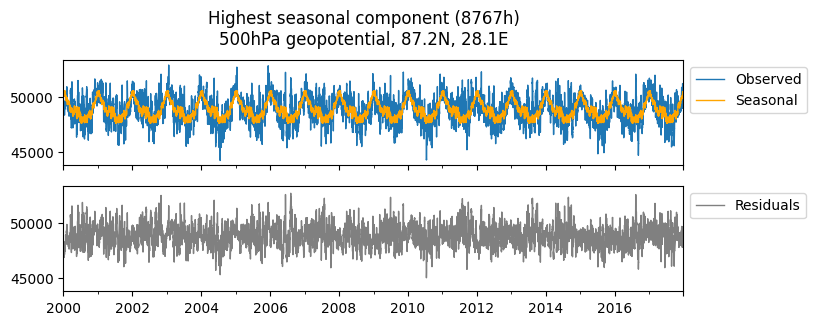

In [188]:
# Ignore the trend; just plot the seasonal component and the (original - seasonal) residual
residual = df - seasonal
fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True, sharey=True)
ax1, ax2 = axs
df.plot(ax=ax1, label='Observed', lw=1, color='C0')
(df.mean() + seasonal).plot(ax=ax1, label='Seasonal', lw=1, color='orange')
residual.plot(lw=1, color='gray', ax=ax2, label='Residuals')
ax1.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax2.legend(bbox_to_anchor=(1, 1), loc='upper left')
fig.suptitle(f'Highest seasonal component ({peaks[0][0]:.0f}h)\n500hPa geopotential, {latitude:.1f}N, {longitude:.1f}E', y=1.05)
fig.savefig('first_decomposition_residuals.png', bbox_inches='tight')

In [172]:
# Calculate the reduction in standard deviation
std_original = df.std()
std_residual = residual.std()
print(f"Percentage standard deviation remaining: {100 * std_residual / std_original:.2f}%")

Percentage standard deviation remaining: 78.82%


# Removing the second highest annual component, after removing the first

In [ ]:
peaks1 = compute_periodogram(residual.values)
res1 = seasonal_decompose(residual, model='additive', extrapolate_trend=True, period=int(peaks1[0][0]))
trend1 = res1.trend
seasonal1 = res1.seasonal

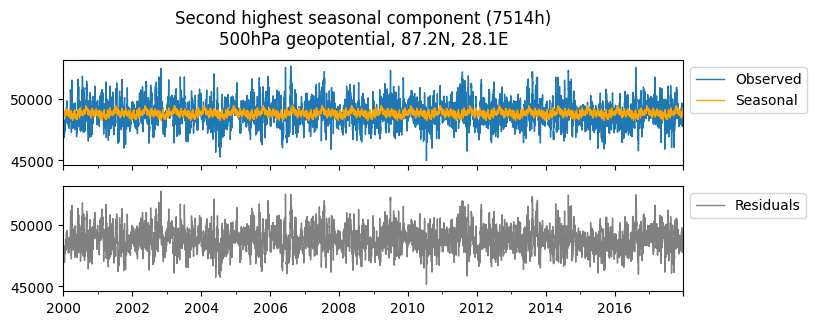

In [194]:
residual1 =  residual - seasonal1
# Ignore the trend; just plot the seasonal component and the (original - seasonal) residual
fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True, sharey=True)
ax1, ax2 = axs
residual.plot(ax=ax1, label='Observed', lw=1, color='C0')
(residual.mean() + seasonal1).plot(ax=ax1, label='Seasonal', lw=1, color='orange')
residual1.plot(lw=1, color='gray', ax=ax2, label='Residuals')
ax1.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax2.legend(bbox_to_anchor=(1, 1), loc='upper left')
fig.suptitle(f'Second highest seasonal component ({peaks1[0][0]:.0f}h)\n500hPa geopotential, {latitude:.1f}N, {longitude:.1f}E', y=1.05)
fig.savefig('second_decomposition_residuals.png', bbox_inches='tight')

In [193]:
# Calculate the reduction in standard deviation
std_original = df.std()
std_residual1 = residual1.std()
print(f"Percentage standard deviation remaining: {100 * std_residual1 / std_original:.2f}%")

Percentage standard deviation remaining: 76.99%
